In [14]:
library(cowplot)
library(data.table)
library(dplyr)
library(ggplot2)
library(qvalue)

In [15]:
# cols_df = as.data.frame(fread('/directflow/SCCGGroupShare/projects/blabow/tenk10k_phase1/plotting_notebooks/overview_figures/manuscript_figures/colour_palette_table.tsv'))
# head(cols_df)

In [16]:
anno_folder = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/review_files/rv_anno_test_results/functional_OR_open/'

In [17]:
# list.files(anno_folder)
celltypes = gsub('_all_cis_rv_set_test_results.tsv','',list.files(anno_folder))
length(celltypes)
celltypes

[1] 26

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_TCM"           "CD8_TEM"           "cDC1"             
[16] "cDC2"              "dnT"               "gdT"              
[19] "HSPC"              "MAIT"              "NK"               
[22] "NK_CD56bright"     "NK_Proliferating"  "pDC"              
[25] "Plasmablast"       "Treg"

In [18]:
no_anno_folder = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'

In [19]:
# # gencode_text_file = '/directflow/SCCGGroupShare/projects/anncuo/reference_data/gencode.v44.basic.annotation_df.txt'
# gencode_text_file = '/share/ScratchGeneral/anncuo/reference_data/gencode.v44.basic.annotation_df.txt'
# gene_info = read.csv(gencode_text_file)
# gene_info$gene = gsub("\\..*","",gene_info$gene_id)
# head(gene_info,2)

In [ ]:
# combined

In [36]:
df_list = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Group == 'Cauchy',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Group == 'Cauchy',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes_burden_functional = nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                            negenes_burden_all = nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                            negenes_skat_functional = nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                            negenes_skat_all = nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,]),
                            celltype = celltype)
    df_list[[celltype]] = df_to_plot
}
df_summary = as.data.frame(rbindlist(df_list))
df_summary$difference_skat = df_summary$negenes_skat_functional - df_summary$negenes_skat_all
df_summary$difference_burden = df_summary$negenes_burden_functional - df_summary$negenes_burden_all
df_summary

negenes_burden_functional,negenes_burden_all,negenes_skat_functional,negenes_skat_all,celltype,difference_skat,difference_burden
<int>,<int>,<int>,<int>,<chr>,<int>,<int>
1,3,8,8,ASDC,0,-2
13,16,126,121,B_intermediate,5,-3
13,15,95,92,B_memory,3,-2
42,48,356,344,B_naive,12,-6
31,42,320,302,CD14_Mono,18,-11
22,28,176,167,CD16_Mono,9,-6
13,14,63,59,CD4_CTL,4,-1
19,19,187,181,CD4_Naive,6,0
2,3,6,5,CD4_Proliferating,1,-1


In [48]:
mean(df_summary$negenes_skat_functional/df_summary$negenes_skat_all)
table(df_summary$negenes_skat_functional > df_summary$negenes_skat_all)
# mean(df_summary$difference_burden)

[1] 0.9893496


FALSE  TRUE 
   12    14 

In [32]:
# dTSS

In [49]:
df_list = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Weight == 'dTSS',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'dTSS',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
#     df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes_burden_functional = nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                            negenes_burden_all = nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                            negenes_skat_functional = nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                            negenes_skat_all = nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,]),
                            celltype = celltype)
    df_list[[celltype]] = df_to_plot
}
df_summary = as.data.frame(rbindlist(df_list))
df_summary$difference_skat = df_summary$negenes_skat_functional - df_summary$negenes_skat_all
df_summary$difference_burden = df_summary$negenes_burden_functional - df_summary$negenes_burden_all
df_summary

negenes_burden_functional,negenes_burden_all,negenes_skat_functional,negenes_skat_all,celltype,difference_skat,difference_burden
<int>,<int>,<int>,<int>,<chr>,<int>,<int>
0,3,6,7,ASDC,-1,-3
10,15,107,80,B_intermediate,27,-5
12,14,80,63,B_memory,17,-2
42,47,318,252,B_naive,66,-5
32,36,283,205,CD14_Mono,78,-4
22,28,156,124,CD16_Mono,32,-6
11,13,56,38,CD4_CTL,18,-2
19,17,162,123,CD4_Naive,39,2
2,3,5,5,CD4_Proliferating,0,-1


In [50]:
mean(df_summary$negenes_skat_functional/df_summary$negenes_skat_all)
table(df_summary$negenes_skat_functional > df_summary$negenes_skat_all)

[1] 1.226919


FALSE  TRUE 
    3    23 

In [35]:
# Beta_1_25

In [61]:
df_list = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Weight == 'Beta_1_25',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'Beta_1_25',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
#     df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df2$qv_burden_anno = qvalue(df2$Pvalue_Burden.anno)$qvalues
    df2$qv_burden_no_anno = qvalue(df2$Pvalue_Burden.no_anno)$qvalues
    df2$qv_skat_anno = qvalue(df2$Pvalue_SKAT.anno)$qvalues
    df2$qv_skat_no_anno = qvalue(df2$Pvalue_SKAT.no_anno)$qvalues
    df_to_plot = data.frame(negenes_burden_functional = nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                            negenes_burden_all = nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                            negenes_skat_functional = nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                            negenes_skat_all = nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,]),
                            celltype = celltype)
    df_list[[celltype]] = df_to_plot
}
df_summary = as.data.frame(rbindlist(df_list))
df_summary$difference_skat = df_summary$negenes_skat_functional - df_summary$negenes_skat_all
df_summary$difference_burden = df_summary$negenes_burden_functional - df_summary$negenes_burden_all
df_summary

negenes_burden_functional,negenes_burden_all,negenes_skat_functional,negenes_skat_all,celltype,difference_skat,difference_burden
<int>,<int>,<int>,<int>,<chr>,<int>,<int>
1,2,8,8,ASDC,0,-1
11,14,108,116,B_intermediate,-8,-3
11,13,89,92,B_memory,-3,-2
37,42,320,334,B_naive,-14,-5
25,38,274,300,CD14_Mono,-26,-13
17,25,149,155,CD16_Mono,-6,-8
12,12,52,56,CD4_CTL,-4,0
16,16,168,186,CD4_Naive,-18,0
2,2,7,6,CD4_Proliferating,1,0


In [63]:
mean(df_summary$negenes_skat_all/df_summary$negenes_skat_functional)
table(df_summary$negenes_skat_functional > df_summary$negenes_skat_all)

[1] 1.094782


FALSE  TRUE 
   24     2 

In [38]:
# Equal_Weights

In [54]:
df_list = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Weight == 'Equal_Weights',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'Equal_Weights',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
#     df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes_burden_functional = nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                            negenes_burden_all = nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                            negenes_skat_functional = nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                            negenes_skat_all = nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,]),
                            celltype = celltype)
    df_list[[celltype]] = df_to_plot
}
df_summary = as.data.frame(rbindlist(df_list))
df_summary$difference_skat = df_summary$negenes_skat_functional - df_summary$negenes_skat_all
df_summary$difference_burden = df_summary$negenes_burden_functional - df_summary$negenes_burden_all
df_summary

negenes_burden_functional,negenes_burden_all,negenes_skat_functional,negenes_skat_all,celltype,difference_skat,difference_burden
<int>,<int>,<int>,<int>,<chr>,<int>,<int>
1,1,7,8,ASDC,-1,0
12,15,114,106,B_intermediate,8,-3
12,14,89,83,B_memory,6,-2
38,42,331,308,B_naive,23,-4
29,38,290,261,CD14_Mono,29,-9
19,27,152,144,CD16_Mono,8,-8
12,12,56,58,CD4_CTL,-2,0
17,17,173,158,CD4_Naive,15,0
2,3,6,5,CD4_Proliferating,1,-1


In [55]:
mean(df_summary$negenes_skat_functional/df_summary$negenes_skat_all)
table(df_summary$negenes_skat_functional > df_summary$negenes_skat_all)

[1] 0.9893496


FALSE  TRUE 
   12    14 

In [41]:
options(repr.plot.width = 6, repr.plot.height = 6)
plist = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    col = cols_df[cols_df$wg2_scpred_prediction == celltype,]$color
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Weight == 'dTSS',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'dTSS',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
#     df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes = c(nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,])),
                       test = c('burden','burden','SKAT','SKAT'),
                       anno = c('functional','all','functional','all'))
    p = ggplot(df_to_plot, aes(x=test, y=negenes, alpha=anno)) 
    p = p + geom_bar(stat='identity', position = 'dodge', fill=col, col='grey')
    p = p + theme_classic() + theme(text = element_text(size=16), legend.position = 'none') 
    p = p + xlab('') + ylab('N eGenes')
    plist[[celltype]] = p + ggtitle(celltype)
}

title <- ggdraw() + 
  draw_label(
    "dTSS",
    fontface = 'bold',
    x = 0.5,  # centered
    hjust = 0.5,
    size = 18
  )

Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warnin

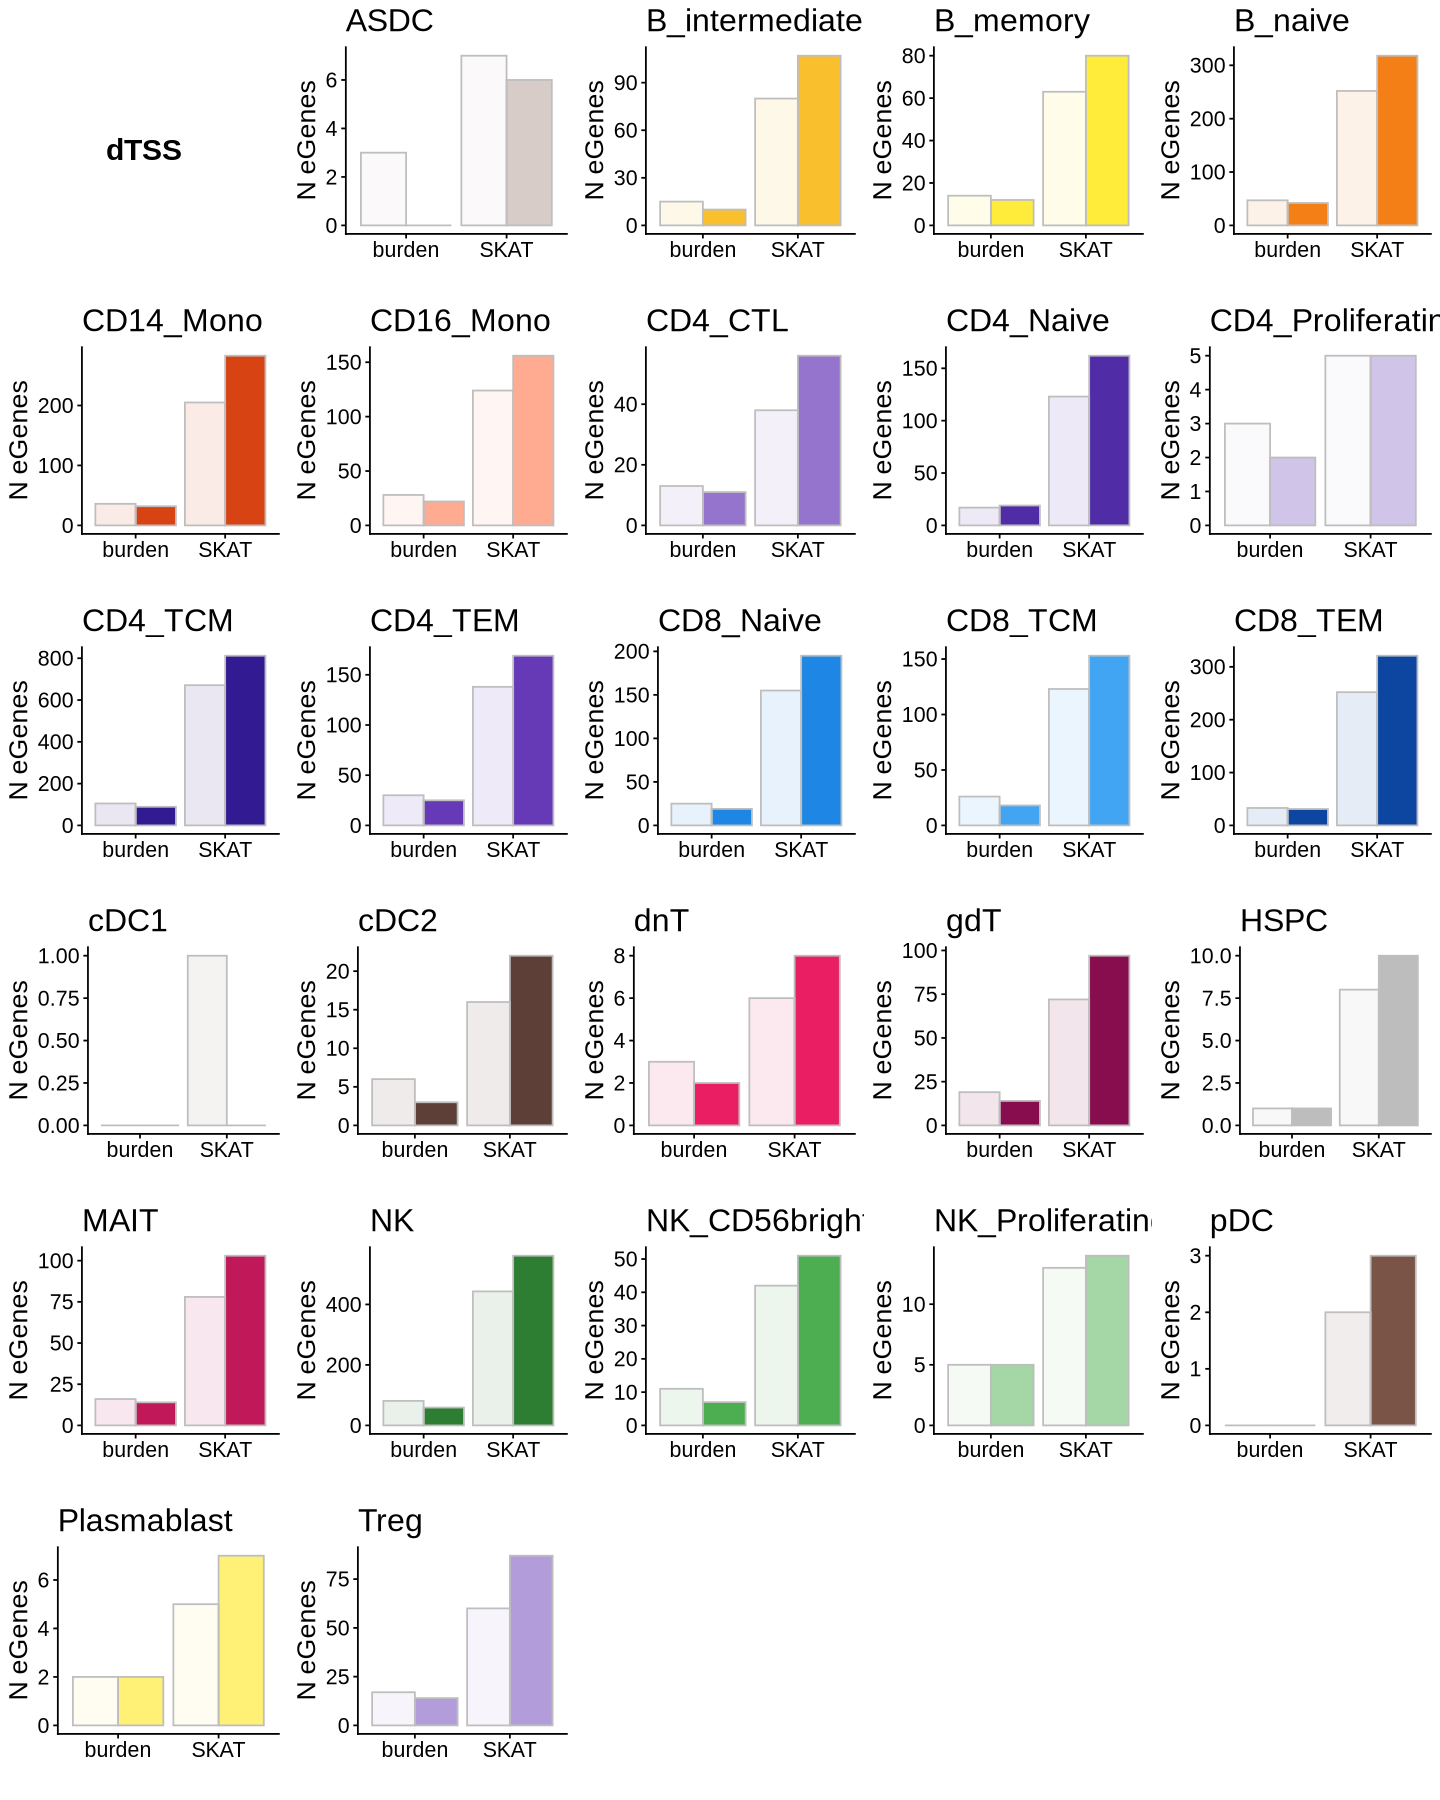

In [42]:
library(cowplot)
options(repr.plot.width = 12, repr.plot.height = 15)
plot_grid(title,plist[[1]],plist[[2]],plist[[3]],plist[[4]],plist[[5]],plist[[6]],plist[[7]],plist[[8]],
          plist[[9]],plist[[10]],plist[[11]],plist[[12]],plist[[13]],plist[[14]],plist[[15]], plist[[16]], 
          plist[[17]], plist[[18]], plist[[19]],plist[[20]],plist[[21]],plist[[22]],plist[[23]],
          plist[[24]],plist[[25]],plist[[26]], ncol = 5)

In [43]:
options(repr.plot.width = 6, repr.plot.height = 6)
plist = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    col = cols_df[cols_df$wg2_scpred_prediction == celltype,]$color
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Weight == 'Equal_Weights',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'Equal_Weights',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
#     df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes = c(nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,])),
                       test = c('burden','burden','SKAT','SKAT'),
                       anno = c('functional','all','functional','all'))
    p = ggplot(df_to_plot, aes(x=test, y=negenes, alpha=anno)) 
    p = p + geom_bar(stat='identity', position = 'dodge', fill=col, col='grey')
    p = p + theme_classic() + theme(text = element_text(size=16), legend.position = 'none') 
    p = p + xlab('') + ylab('N eGenes')
    plist[[celltype]] = p + ggtitle(celltype)
}

title <- ggdraw() + 
  draw_label(
    "Equal_Weights",
    fontface = 'bold',
    x = 0.5,  # centered
    hjust = 0.5,
    size = 18
  )

Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warnin

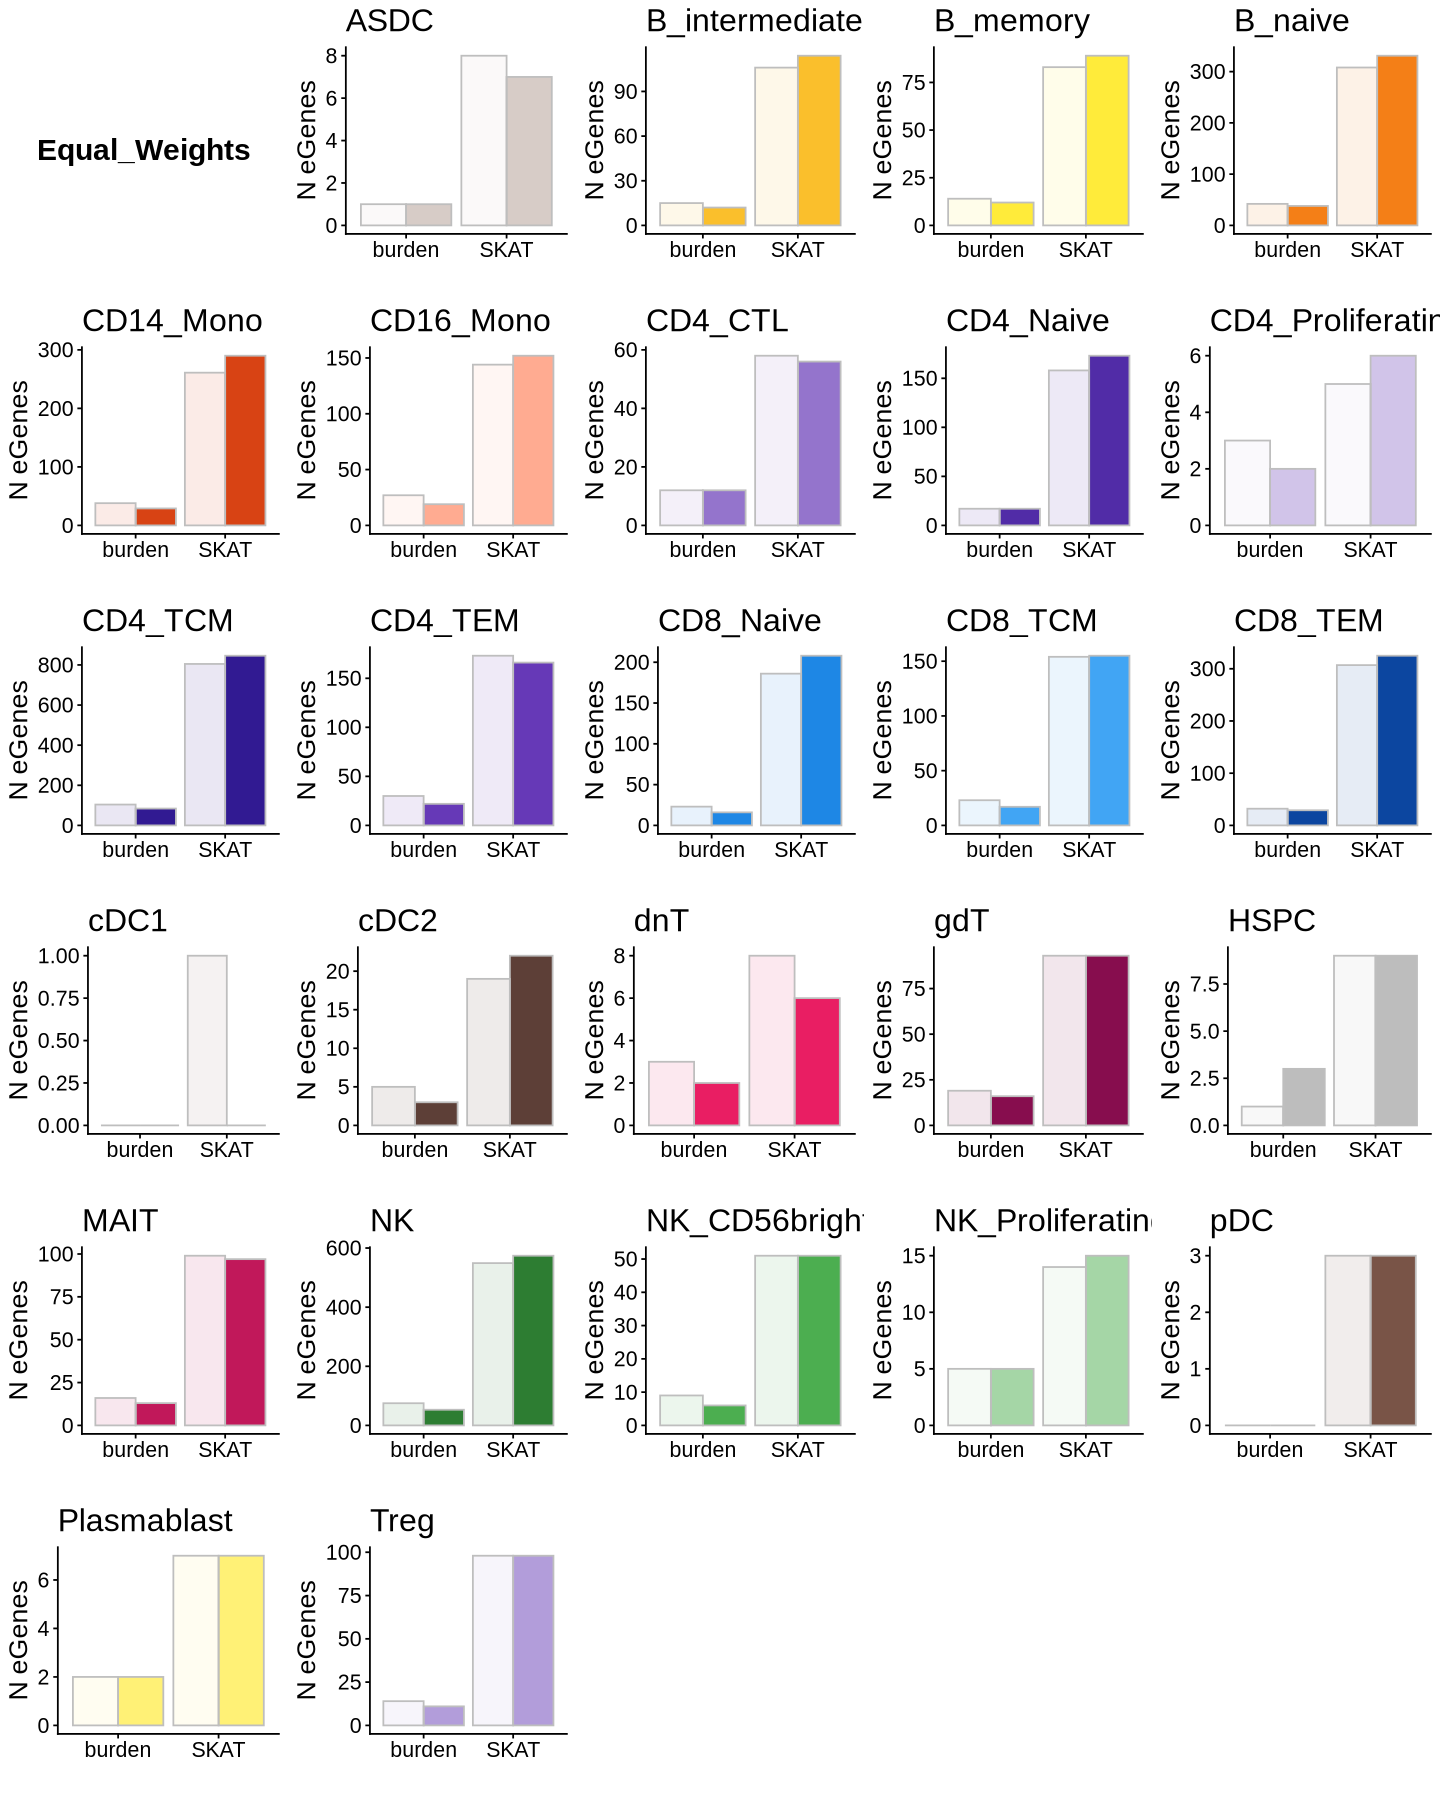

In [44]:
library(cowplot)
options(repr.plot.width = 12, repr.plot.height = 15)
plot_grid(title, plist[[1]],plist[[2]],plist[[3]],plist[[4]],plist[[5]],plist[[6]],plist[[7]],plist[[8]],
          plist[[9]],plist[[10]],plist[[11]],plist[[12]],plist[[13]],plist[[14]],plist[[15]], plist[[16]], 
          plist[[17]], plist[[18]], plist[[19]],plist[[20]],plist[[21]],plist[[22]],plist[[23]],
          plist[[24]],plist[[25]],plist[[26]], ncol = 5)

In [45]:
options(repr.plot.width = 6, repr.plot.height = 6)
plist = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    col = cols_df[cols_df$wg2_scpred_prediction == celltype,]$color
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Weight == 'Beta_1_25',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'Beta_1_25',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
#     df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes = c(nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,])),
                       test = c('burden','burden','SKAT','SKAT'),
                       anno = c('functional','all','functional','all'))
    p = ggplot(df_to_plot, aes(x=test, y=negenes, alpha=anno)) 
    p = p + geom_bar(stat='identity', position = 'dodge', fill=col, col='grey')
    p = p + theme_classic() + theme(text = element_text(size=16), legend.position = 'none') 
    p = p + xlab('') + ylab('N eGenes')
    plist[[celltype]] = p + ggtitle(celltype)
}

title <- ggdraw() + 
  draw_label(
    "Beta_1_25",
    fontface = 'bold',
    x = 0.5,  # centered
    hjust = 0.5,
    size = 18
  )

Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warnin

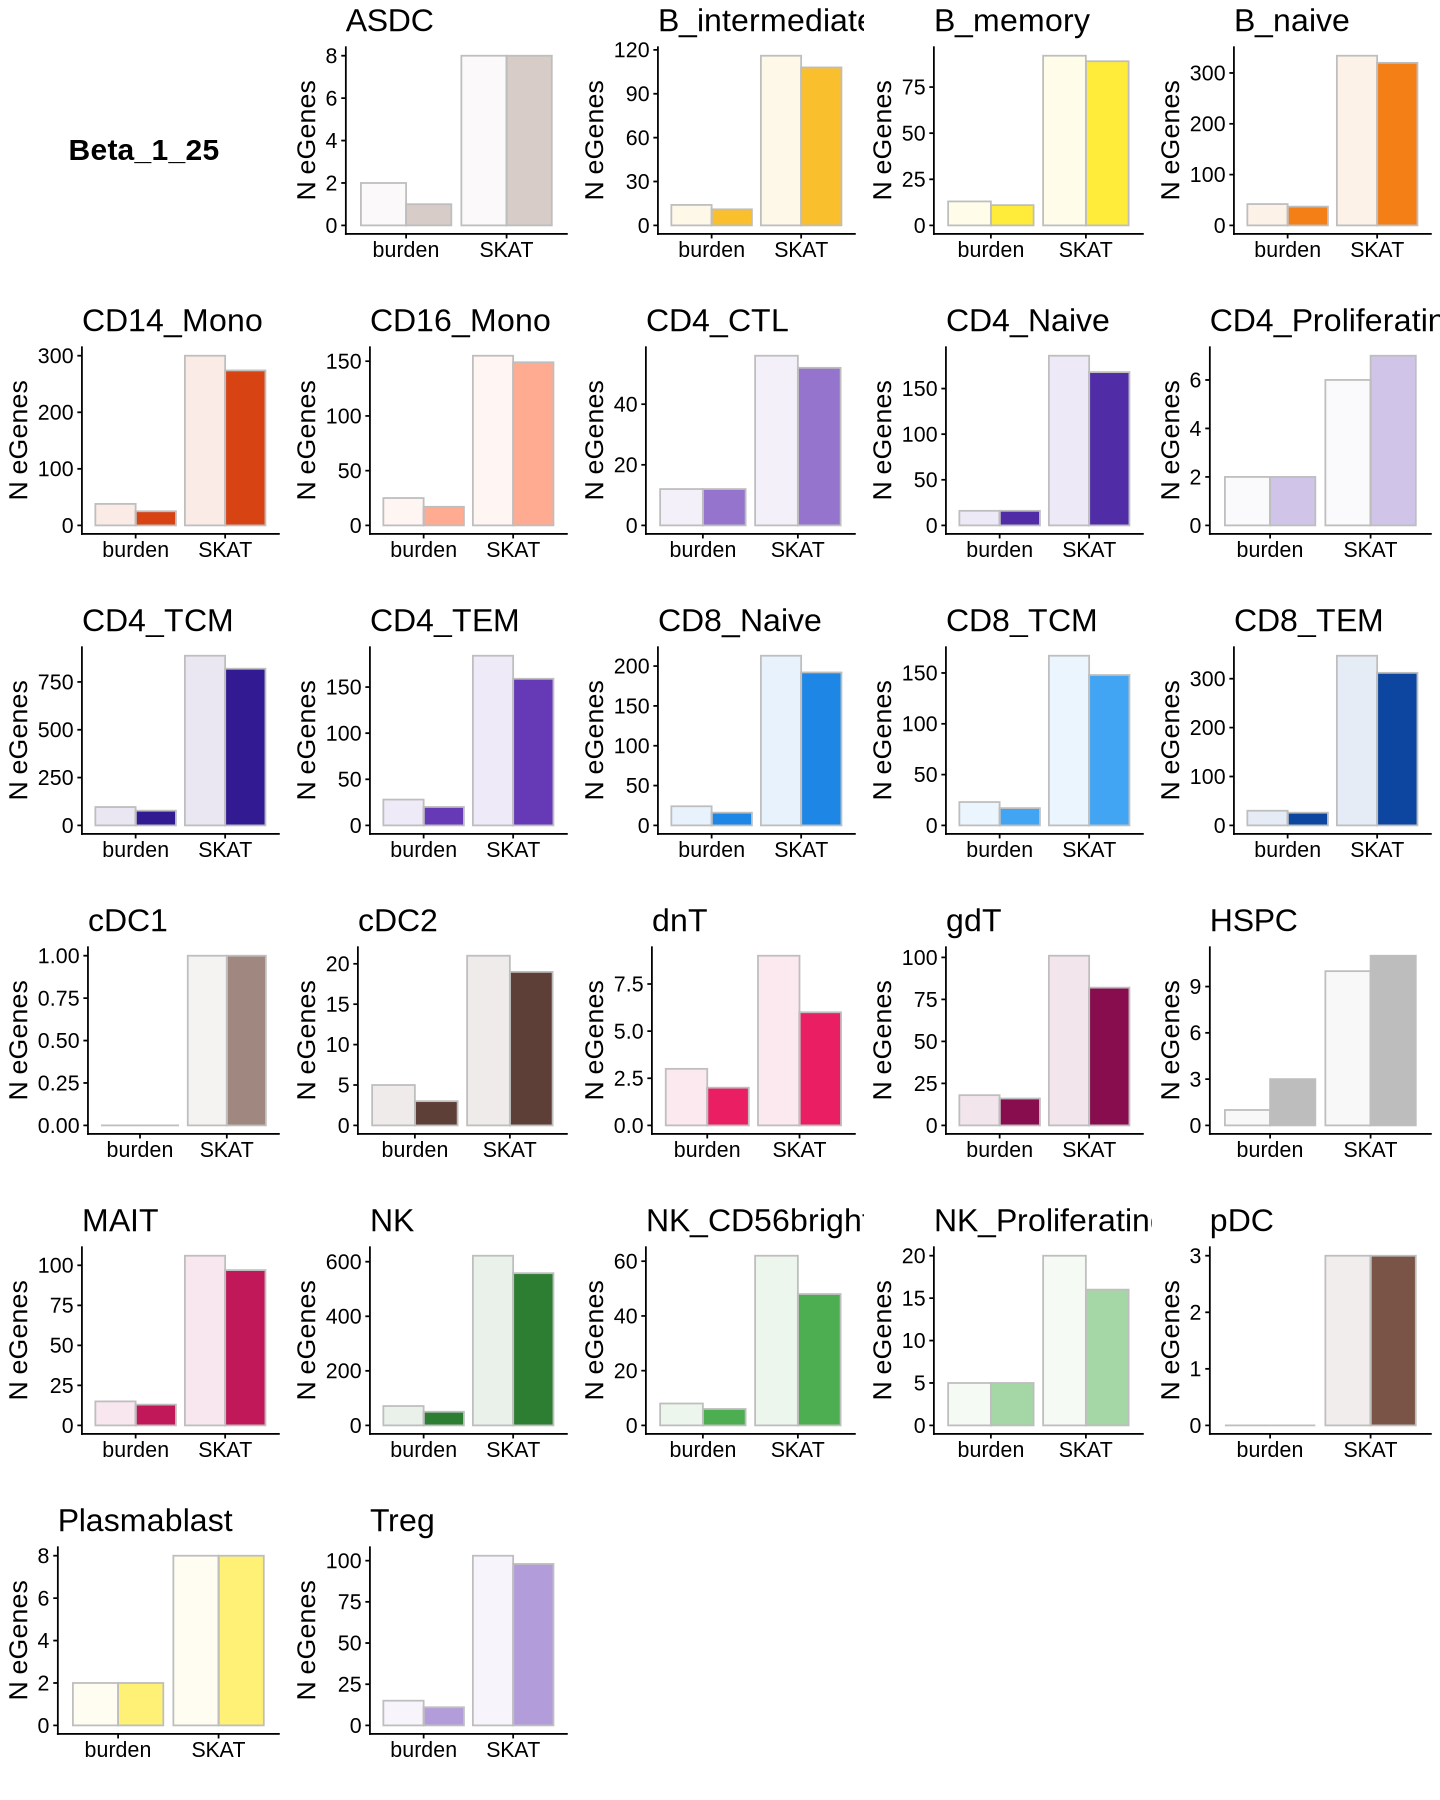

In [46]:
library(cowplot)
options(repr.plot.width = 12, repr.plot.height = 15)
plot_grid(title, plist[[1]],plist[[2]],plist[[3]],plist[[4]],plist[[5]],plist[[6]],plist[[7]],plist[[8]],
          plist[[9]],plist[[10]],plist[[11]],plist[[12]],plist[[13]],plist[[14]],plist[[15]], plist[[16]], 
          plist[[17]], plist[[18]], plist[[19]],plist[[20]],plist[[21]],plist[[22]],plist[[23]],
          plist[[24]],plist[[25]],plist[[26]], ncol = 5)

In [47]:
plist = list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    col = cols_df[cols_df$wg2_scpred_prediction == celltype,]$color
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub(paste0('_functional_OR_open_',celltype),'',df1$Region)
    df00 = df0[df0$Group == 'Cauchy',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Group == 'Cauchy',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    df_to_plot = data.frame(negenes = c(nrow(df2[df2$Pvalue_Burden.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_Burden.no_anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.anno<1e-6,]),
                                    nrow(df2[df2$Pvalue_SKAT.no_anno<1e-6,])),
                       test = c('burden','burden','SKAT','SKAT'),
                       anno = c('functional','all','functional','all'))
    p = ggplot(df_to_plot, aes(x=test, y=negenes, alpha=anno)) 
    p = p + geom_bar(stat='identity', position = 'dodge', fill=col, col='grey')
    p = p + theme_classic() + theme(text = element_text(size=16), legend.position = 'none')  
    p = p + xlab('') + ylab('N eGenes')
    plist[[celltype]] = p + ggtitle(celltype)
}
title <- ggdraw() + 
  draw_label(
    "Combined",
    fontface = 'bold',
    x = 0.5,  # centered
    hjust = 0.5,
    size = 18
  )

Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warning message:
“Using alpha for a discrete variable is not advised.”
Warnin

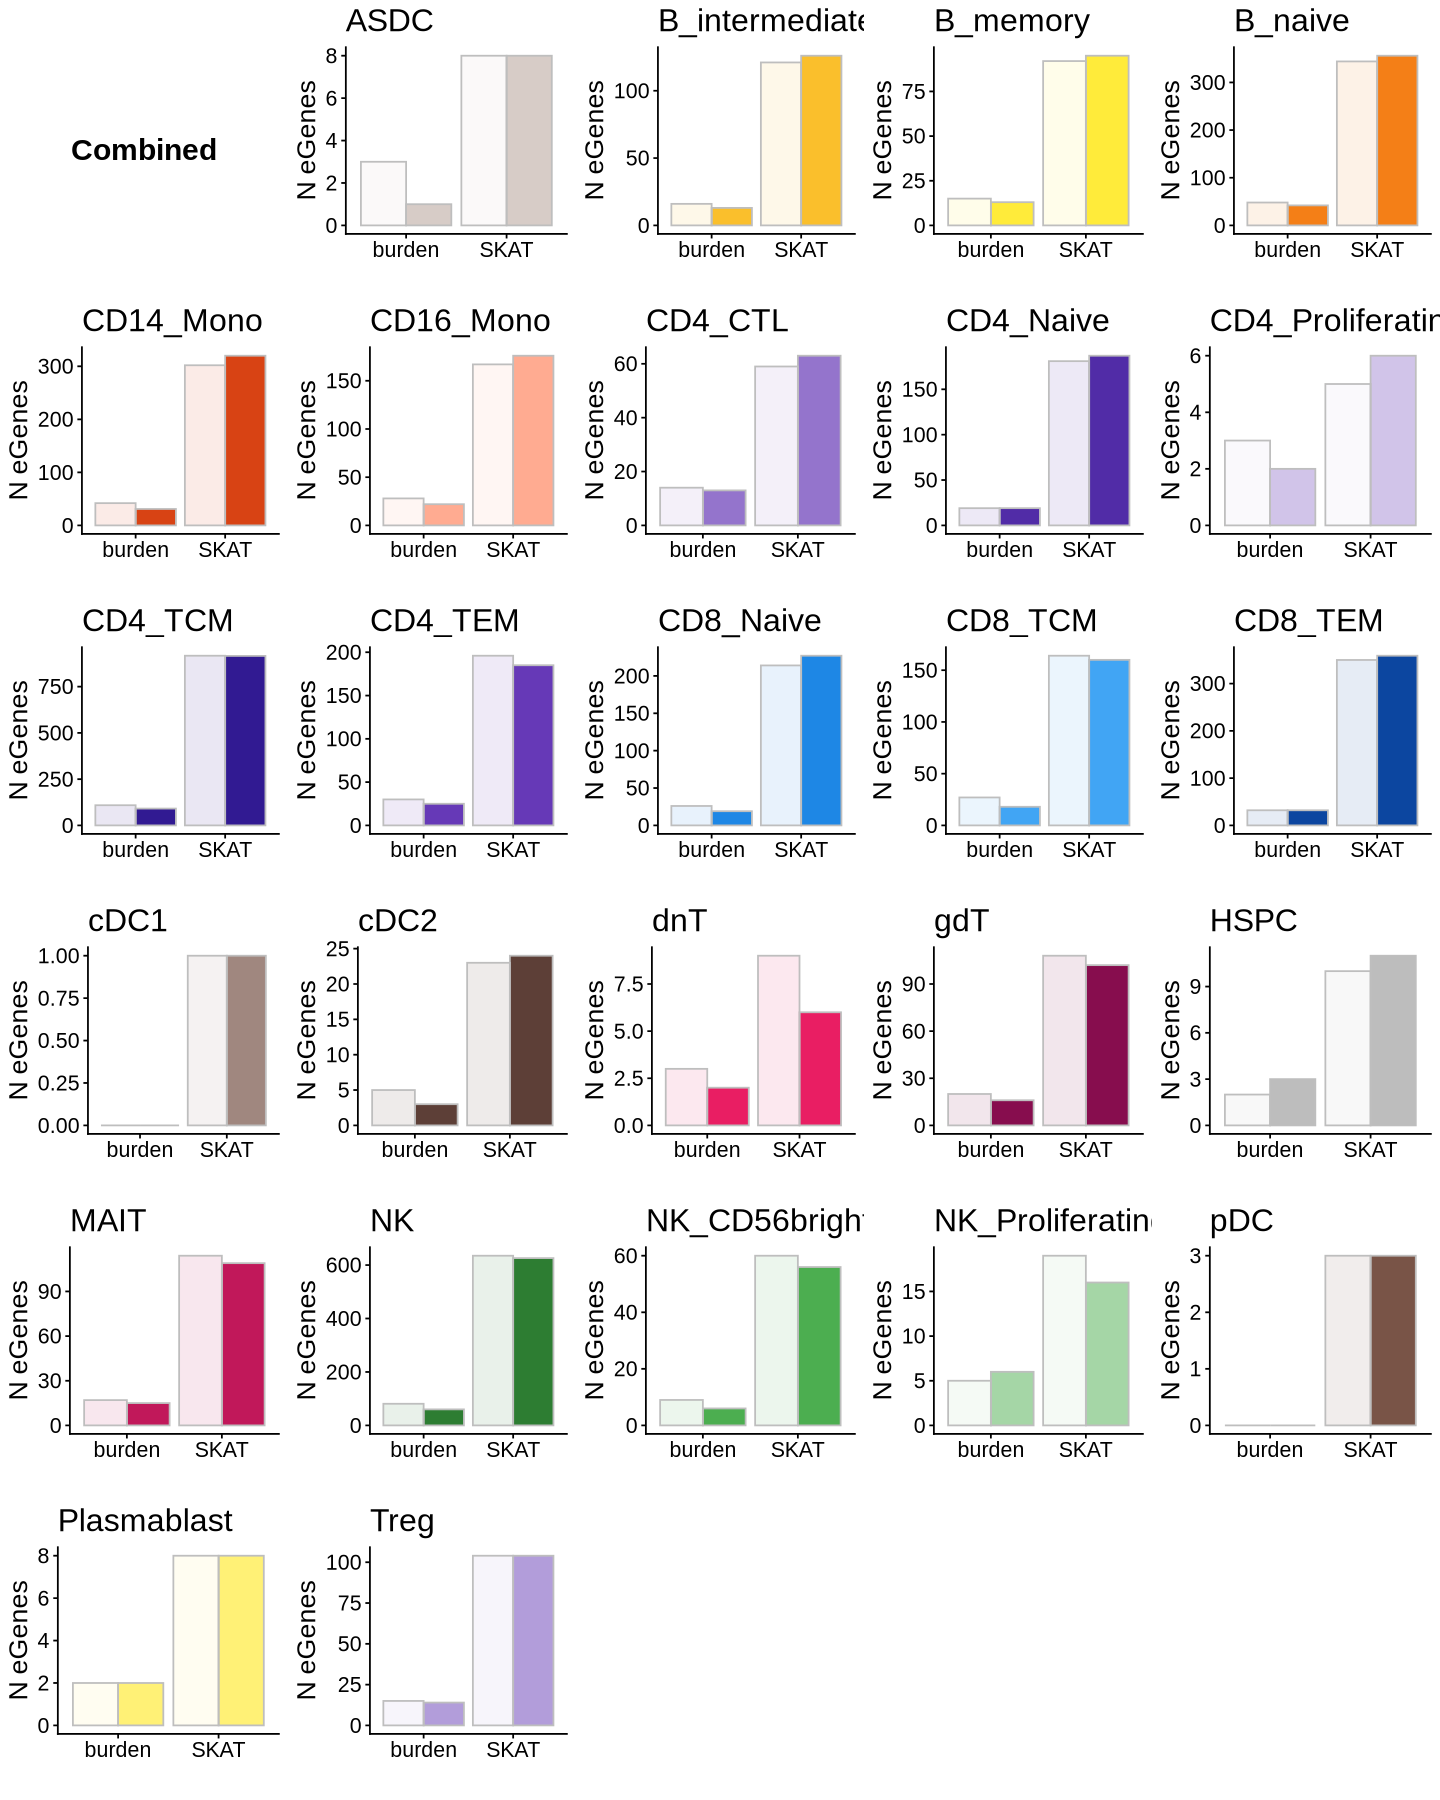

In [48]:
library(cowplot)
options(repr.plot.width = 12, repr.plot.height = 15)
plot_grid(title, plist[[1]],plist[[2]],plist[[3]],plist[[4]],plist[[5]],plist[[6]],plist[[7]],plist[[8]],
          plist[[9]],plist[[10]],plist[[11]],plist[[12]],plist[[13]],plist[[14]],plist[[15]], plist[[16]], 
          plist[[17]], plist[[18]], plist[[19]],plist[[20]],plist[[21]],plist[[22]],plist[[23]],
          plist[[24]],plist[[25]],plist[[26]], ncol = 5)

In [49]:
options(repr.plot.width = 12, repr.plot.height = 6)
plist=list()
for (celltype in celltypes){
    no_anno_file = paste0(no_anno_folder,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    anno_file = paste0(anno_folder,celltype,'_all_cis_rv_set_test_results.tsv')
    col = cols_df[cols_df$wg2_scpred_prediction == celltype,]$color
    df0 = as.data.frame(fread(no_anno_file))
    df0$gene = df0$Region
    df1 = as.data.frame(fread(anno_file))
    df1$gene = gsub('_functional','',df1$Region)
    df1$gene = gsub('_functional','',df1$Region)
    df00 = df0[df0$Weight == 'dTSS',]
    df00 <- df00[rowSums(is.na(df00)) != ncol(df00), ]
    df10 = df1[df1$Weight == 'dTSS',]
    df10 <- df10[rowSums(is.na(df10)) != ncol(df10), ]
    df10 = df10[df10$Number_rare>500,]
    df2 = inner_join(df00,df10, by='gene', suffix=c('.no_anno','.anno'))
    p = ggplot(df2, aes(x=-log10(Pvalue_Burden.no_anno),y=-log10(Pvalue_Burden.anno))) 
    p = p + geom_point(col=col) + theme_classic() + geom_abline() 
    p = p + xlab('all variants') + ylab('functional variants')
    p = p + theme(text = element_text(size=20), legend.position = 'none') 
    p1 = p + ggtitle(paste0(celltype,', burden'))
    p = ggplot(df2, aes(x=-log10(Pvalue_SKAT.no_anno),y=-log10(Pvalue_SKAT.anno))) 
    p = p + geom_point(col=col) + theme_classic() + geom_abline() 
    p = p + xlab('all variants') + ylab('functional \nvariants')
    p = p + theme(text = element_text(size=20), legend.position = 'none') 
    p2 = p + ggtitle(paste0(celltype,', SKAT'))
    plist[[celltype]] = plot_grid(p1, p2, ncol = 2)
}

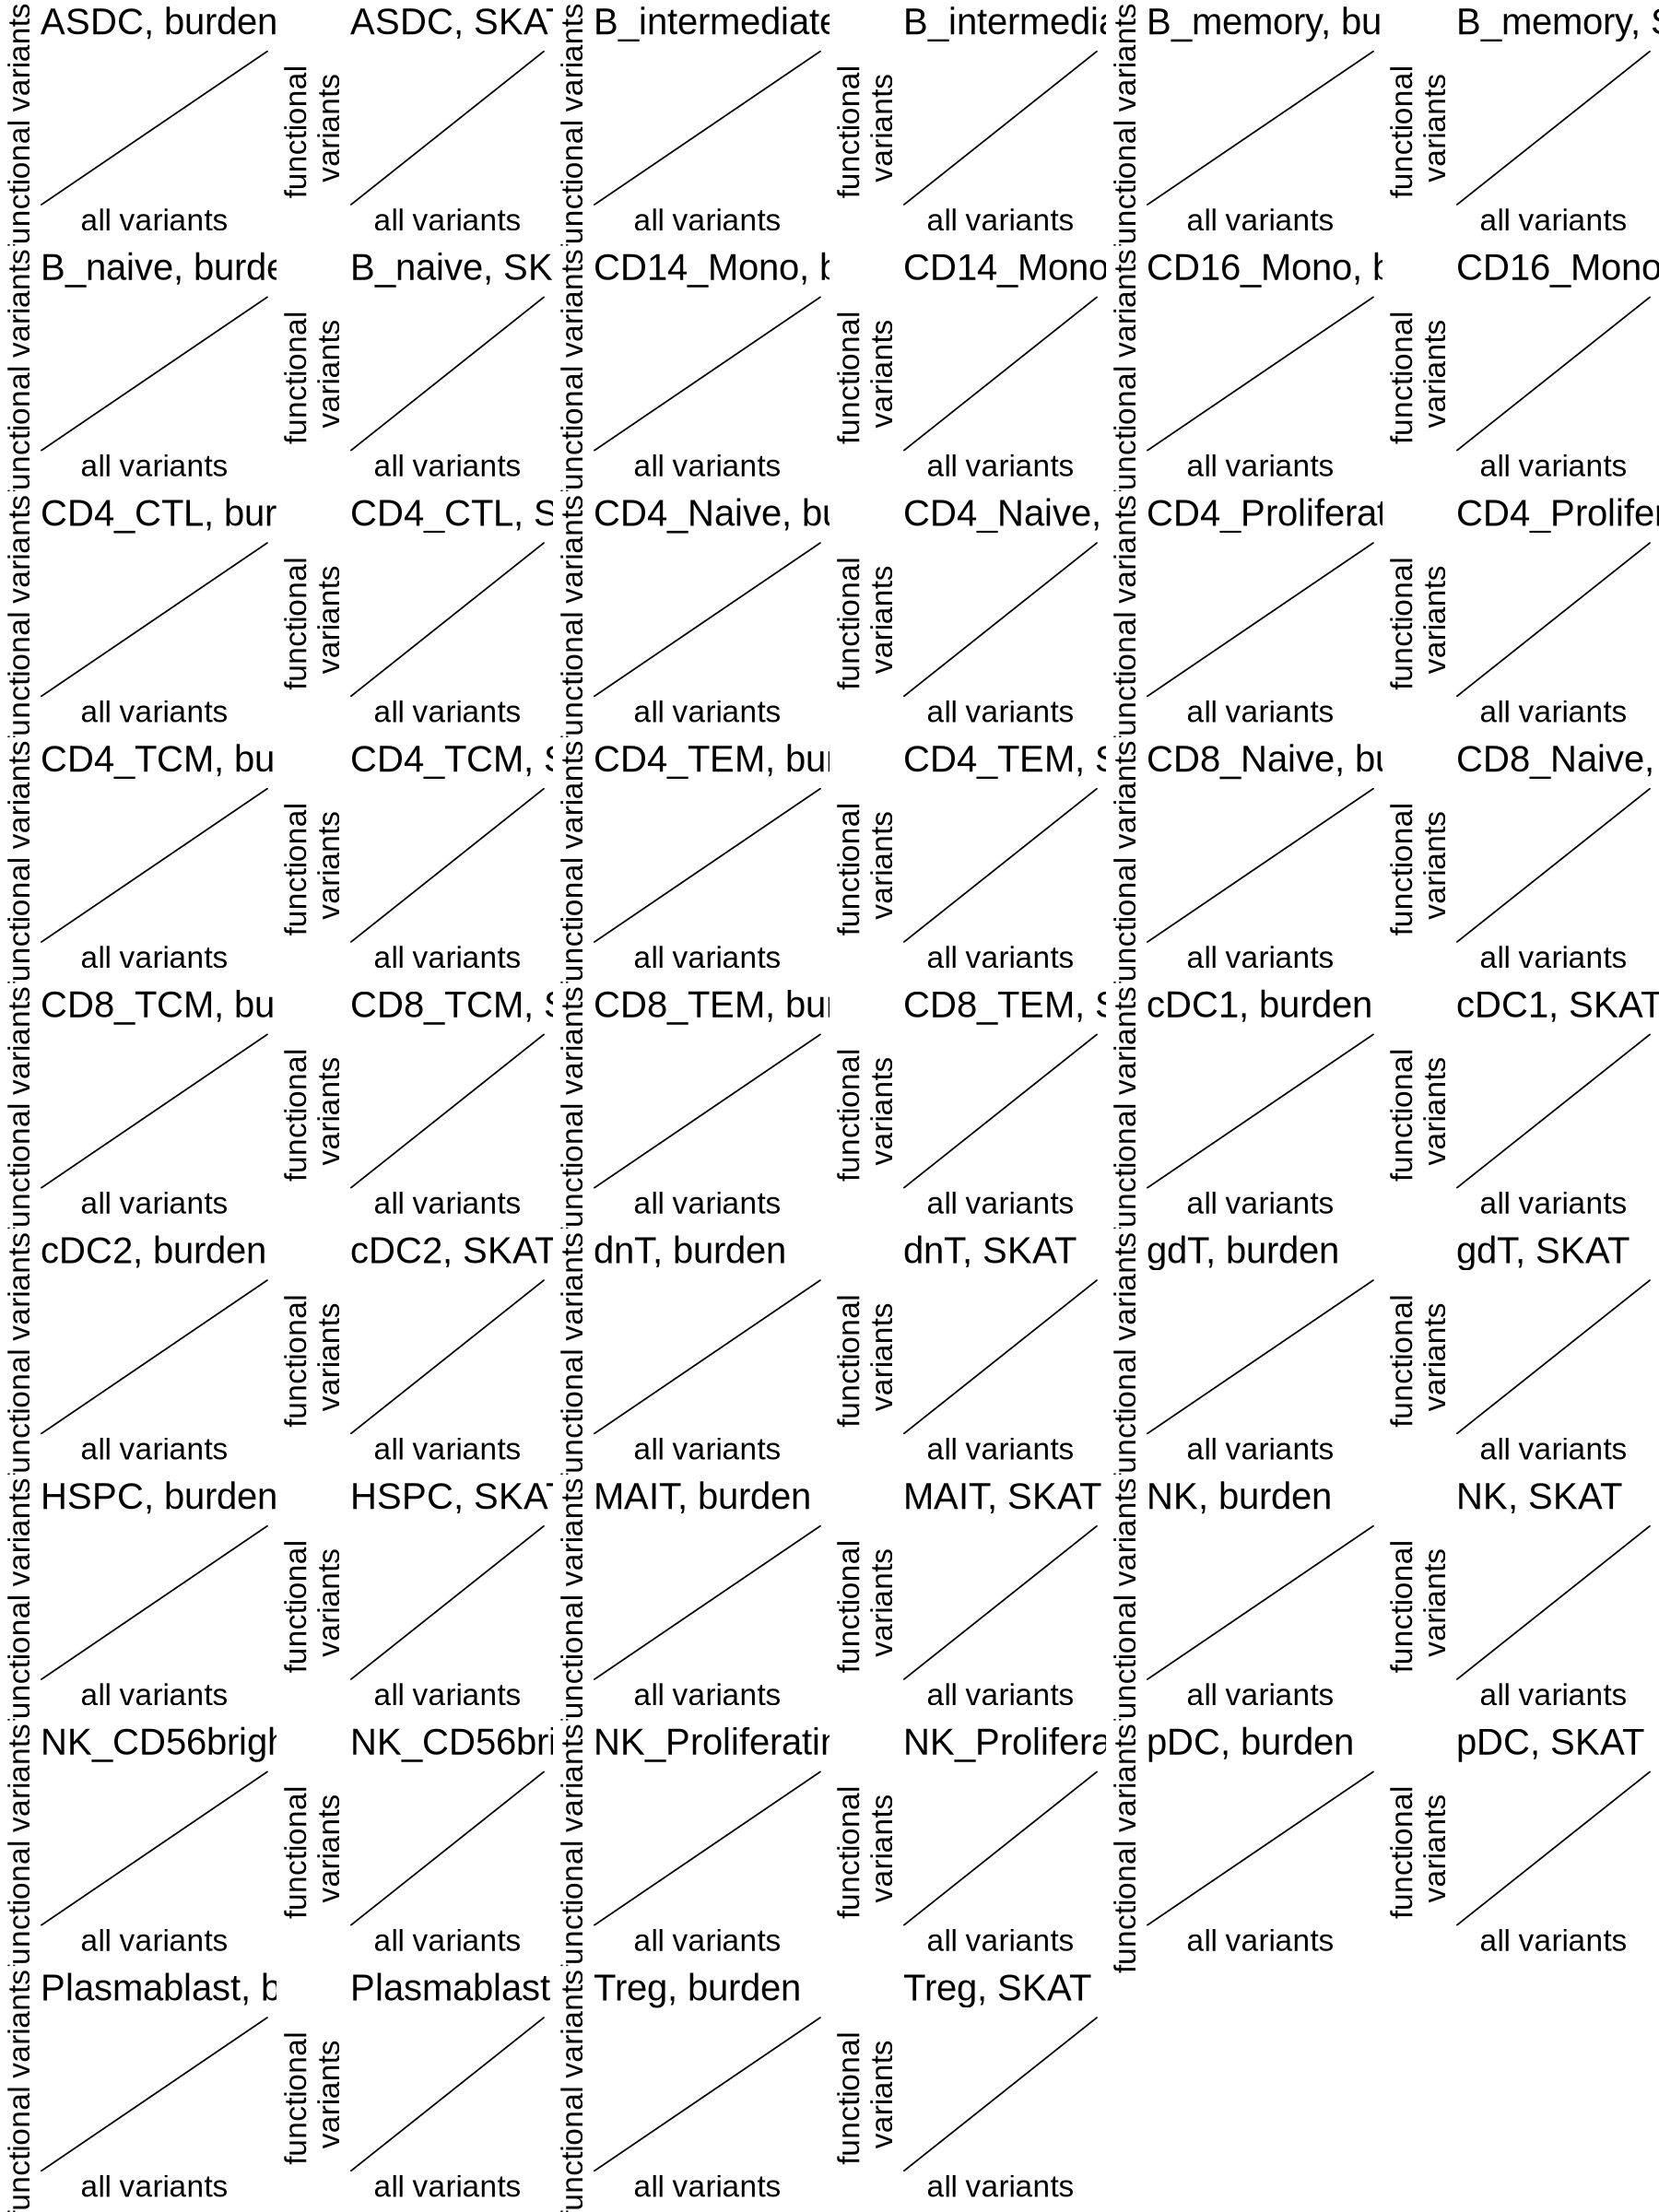

In [50]:
library(cowplot)
options(repr.plot.width = 15, repr.plot.height = 20)
plot_grid(plist[[1]],plist[[2]],plist[[3]],plist[[4]],plist[[5]],plist[[6]],plist[[7]],plist[[8]],
          plist[[9]],plist[[10]],plist[[11]],plist[[12]],plist[[13]],plist[[14]],plist[[15]], plist[[16]], 
          plist[[17]], plist[[18]], plist[[19]],plist[[20]],plist[[21]],plist[[22]],plist[[23]],
          plist[[24]],plist[[25]],plist[[26]], ncol = 3)